# Breast Cancer Wisconsin (Original)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

Medicina: mediciones de núcleos celulares para clasificar tumores (UCI).

### Tarea de machine learning
- **Tipo de tarea**: clasificación binaria
- **Variable objetivo**: `class`: 2 benigno, 4 maligno.

Las siguientes celdas cargan datos y muestran `head`, `shape`, `dtypes` y `describe`.

In [1]:
import warnings  # Avisos
warnings.filterwarnings("ignore")  # Ocultar
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # Tablas
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Stats
from IPython.display import display  # Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto

df = pd.read_csv(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/8. Breast Cancer Wisconsin (Original) – UCI/breast+cancer+wisconsin+original/breast-cancer-wisconsin.data", header=None, names=['id', 'clump', 'cell_size', 'cell_shape', 'marginal', 'epithelial', 'bare_nuclei', 'bland', 'nucleoli', 'mitoses', 'class'], na_values="?")  # Cargar
display(df.head(10))  # Muestra
print(df.shape)  # Forma
display(df.describe(include="all").T)  # Stats


,id,clump,cell_size,cell_shape,marginal,epithelial,bare_nuclei,bland,nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
5,1017122,8,10,10,8,7,10.0,9,7,1,4
6,1018099,1,1,1,1,2,10.0,3,1,1,2
7,1018561,2,1,2,1,2,1.0,3,1,1,2
8,1033078,2,1,1,1,2,1.0,1,1,5,2
9,1033078,4,2,1,1,2,1.0,2,1,1,2


(699, 11)


,count,mean,std,min,25%,50%,75%,max
id,699.0,1.071704e+06,617095.729819,61634.0,870688.5,1171710.0,1238298.0,13454352.0
clump,699.0,4.417740e+00,2.815741,1.0,2.0,4.0,6.0,10.0
cell_size,699.0,3.134478e+00,3.051459,1.0,1.0,1.0,5.0,10.0
cell_shape,699.0,3.207439e+00,2.971913,1.0,1.0,1.0,5.0,10.0
marginal,699.0,2.806867e+00,2.855379,1.0,1.0,1.0,4.0,10.0
epithelial,699.0,3.216023e+00,2.214300,1.0,2.0,2.0,4.0,10.0
bare_nuclei,683.0,3.544656e+00,3.643857,1.0,1.0,1.0,6.0,10.0
bland,699.0,3.437768e+00,2.438364,1.0,2.0,3.0,5.0,10.0
nucleoli,699.0,2.866953e+00,3.053634,1.0,1.0,1.0,4.0,10.0
mitoses,699.0,1.589413e+00,1.715078,1.0,1.0,1.0,1.0,10.0


## SECCIÓN 1

In [2]:
df1 = df.copy()  # Copia para limpiar
print("Nulos ANTES por columna (top):\n", df1.isnull().sum().sort_values(ascending=False).head(15))  # Conteo
df1 = df1.drop_duplicates()  # Eliminar filas duplicadas
nr = df1.isnull().mean()  # Fraccion nulos
drop_null = nr[nr > 0.40].index.tolist()  # Columnas >40% nulos
print("Eliminadas por >40% nulos:", drop_null)  # Motivo: poca informacion
df1 = df1.drop(columns=drop_null, errors="ignore")  # Borrar
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for c in num_cols:
    df1[c] = df1[c].fillna(df1[c].median())  # Mediana (robusta a outliers)
for c in cat_cols:
    if df1[c].isnull().any():
        mod = df1[c].mode()
        df1[c] = df1[c].fillna(mod.iloc[0] if len(mod) else "")  # Moda
print("Nulos DESPUES (total):", int(df1.isnull().sum().sum()))  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES por columna (top):
 bare_nuclei    16
clump           0
id              0
cell_size       0
cell_shape      0
marginal        0
epithelial      0
bland           0
nucleoli        0
mitoses         0
class           0
dtype: int64
Eliminadas por >40% nulos: []
Nulos DESPUES (total): 0


## SECCIÓN 2

X.shape (691, 9) y.shape (691,)
class
0    453
1    238
Name: count, dtype: int64


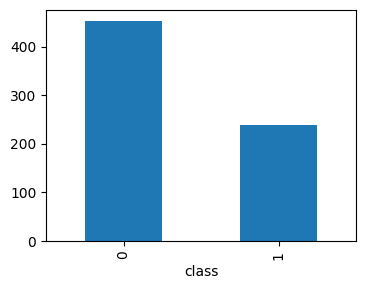

Top corr: cell_size      0.817720
cell_shape     0.817693
bare_nuclei    0.816787
bland          0.756618
clump          0.716938
dtype: float64


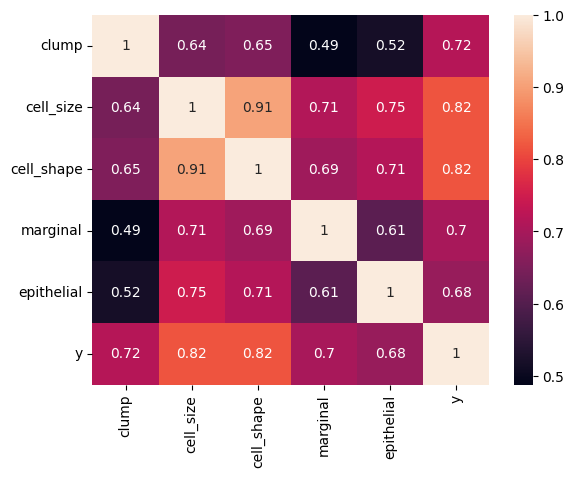

In [3]:
y = (df_clean["class"] == 4).astype(int)  # 1 maligno
X = df_clean.drop(columns=["class"])  # Sin clase
if "id" in X.columns:
    X = X.drop(columns=["id"])  # Quitar ID
print("X.shape", X.shape, "y.shape", y.shape)  # Shapes
print(y.value_counts())  # Clases
plt.figure(figsize=(4,3))  # Figura
y.value_counts().plot(kind="bar")  # Barras
plt.show()  # Grafico
num_x = X.select_dtypes(include=[np.number]).columns  # Numericas
print("Top corr:", X[num_x].corrwith(y).abs().sort_values(ascending=False).head(5))  # Top 5
sns.heatmap(pd.concat([X[num_x[:5]], y.rename("y")], axis=1).corr(), annot=True)  # Heatmap
plt.show()


## SECCIÓN 3 — Solo numéricas (sin one-hot obligatorio)

In [4]:
X_enc = X.copy()  # Ya numericas
print("Columnas:", X_enc.columns.tolist())  # Lista
display(X_enc.head(5))  # Muestra


Columnas: ['clump', 'cell_size', 'cell_shape', 'marginal', 'epithelial', 'bare_nuclei', 'bland', 'nucleoli', 'mitoses']


,clump,cell_size,cell_shape,marginal,epithelial,bare_nuclei,bland,nucleoli,mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


## SECCIÓN 4

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste global
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DF
antes = X_enc.iloc[:5, :min(6, X_enc.shape[1])]  # 5 filas antes
despues = X_scaled_df.iloc[:5, :min(6, X_scaled_df.shape[1])]  # 5 filas despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES                                                        DESPUES  \
  clump cell_size cell_shape marginal epithelial bare_nuclei     clump   
0     5         1          1        1          2         1.0  0.203667   
1     5         4          4        5          7        10.0  0.203667   
2     3         1          1        1          2         2.0 -0.507110   
3     6         8          8        1          3         4.0  0.559055   
4     4         1          1        3          2         1.0 -0.151722   

                                                         
  cell_size cell_shape  marginal epithelial bare_nuclei  
0 -0.700940  -0.744202 -0.637077  -0.551021   -0.686127  
1  0.286185   0.270085  0.759339   1.723505    1.804838  
2 -0.700940  -0.744202 -0.637077  -0.551021   -0.409353  
3  1.602353   1.622467 -0.637077  -0.096116    0.144195  
4 -0.700940  -0.744202  0.061131  -0.551021   -0.686127

## SECCIÓN 5

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)  # Estratificado
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Tamano


Shapes: (552, 9) (139, 9) (552,) (139,)


## SECCIÓN 6

In [7]:
clf = LogisticRegression(max_iter=1000)  # Modelo
clf.fit(X_train, y_train)  # Entrenar
acc = accuracy_score(y_test, clf.predict(X_test))  # Accuracy
print("Accuracy:", acc)  # Resultado
score_breast = acc  # Score


Accuracy: 0.9640287769784173


## SECCIÓN 7

In [8]:
out = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/8. Breast Cancer Wisconsin (Original) – UCI")  # Carpeta
pd.concat([X_scaled_df, y.rename("malignant")], axis=1).to_csv(out / "breast_cancer_wisconsin_clean.csv", index=False)  # Limpio
X_train.to_csv(out / "X_train.csv", index=False)  # Train
X_test.to_csv(out / "X_test.csv", index=False)  # Test
y_train.to_csv(out / "y_train.csv", index=True, header=True)  # y
y_test.to_csv(out / "y_test.csv", index=True, header=True)  # y test
print("Guardado breast_cancer_wisconsin_clean.csv")  # Ok


Guardado breast_cancer_wisconsin_clean.csv


## SECCIÓN 8

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0
print("RESUMEN Breast | Acc:", round(acc, 4))  # Resumen


,id,clump,cell_size,cell_shape,marginal,epithelial,bare_nuclei,bland,nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
5,1017122,8,10,10,8,7,10.0,9,7,1,4
6,1018099,1,1,1,1,2,10.0,3,1,1,2
7,1018561,2,1,2,1,2,1.0,3,1,1,2
8,1033078,2,1,1,1,2,1.0,1,1,5,2
9,1033078,4,2,1,1,2,1.0,2,1,1,2


RESUMEN Breast | Acc: 0.964
